# Hierarchical Bayesian Analysis of SEIRD ABM Outputs
## Bayesian Modeling of Complexity — Final Paper Notebook

**Research question:** Does the health ministry alert system reduce epidemic wave severity, and is this effect moderated by zone-level compliance — after accounting for transmission rate and stochastic run-to-run variability?

**Approach:** A SEIRD ABM was run under a factorial design: 5 transmission rates × 2 residential zones × 20 stochastic runs × 2 policy conditions (ON/OFF) = 400 simulations. Each agent draws individual personality parameters (compliance, doctor probability, immunity duration, transport mode) from zone-specific priors, producing realistic heterogeneity.

The outcome is `mean_peak_infectious`: the mean height of detected epidemic wave peaks across the 365-day simulation. A hierarchical Normal model with group-level varying intercepts (partial pooling across 10 β₀×zone groups) estimates the policy effect and its moderation by zone compliance.


## 0. Dependencies

Import the required packages.
run `brew install warnings numpy pandas matplotlib pymc arviz` (or equivalent) prior to running the cell to dowload the packages.

In [67]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib as plt
import matplotlib.patches as mpatches
import pymc as pm
import arviz as az

print(f'PyMC  {pm.__version__}')
print(f'ArviZ {az.__version__}')
print(f'Pandas {pd.__version__}')
print(f'NumPy {np.__version__}')
print(f'MatPlotLib {plt.__version__}')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


PyMC  6.0.1
ArviZ 1.1.0
Pandas 3.0.2
NumPy 2.4.4
MatPlotLib 3.10.8


## 1. Data Loading and Exploration

### 1.0 Data source
The dataset is generated by the Agent-Based SEIRD model which Anna and I designed based on our ODD protocol. For the purpose of this analysis, I extended the model by implementing some features that I would have liked to include if I had had enough time in the beginning of May. Notably, this enhanced model acounts for agent-level personality heterogeneity, drawing each agent's behavioral preferences randomly from a residence-based prior. Agents are now fully heterogeneous in their probability to visit a doctor, their compliance with government policy, and their immune response, producing realistic variation in epidemic dynamics across random runs.

This cell loads and provides a glimpse into the data. All variables and the 8 first rows are visible.

In [24]:
df = pd.read_csv('abm_outputs.csv')
print(f'Shape: {df.shape}  ({df.policy_active.nunique()} policy conditions × '
      f'{df[df.policy_active==1].shape[0]} ON rows + {df[df.policy_active==0].shape[0]} OFF rows)')
print(f'Groups: {df.group_id.nunique()}  |  Runs per group per policy: {df.groupby(["group_id","policy_active"]).size().unique()[0]}')
print()
print(df[['group_label','beta0','zone','policy_active','mean_peak_infectious',
          'n_waves','policy_effect','mean_compliance']].head(8).to_string(index=False))


Shape: (400, 29)  (2 policy conditions × 200 ON rows + 200 OFF rows)
Groups: 10  |  Runs per group per policy: 20

 group_label  beta0            zone  policy_active  mean_peak_infectious  n_waves  policy_effect  mean_compliance
b0.010_dense   0.01 dense_periphery              0                 45.90       10       0.259259           0.2712
b0.010_dense   0.01 dense_periphery              1                 34.00       10       0.259259           0.2713
b0.010_dense   0.01 dense_periphery              0                 43.55       11      -0.188289           0.2602
b0.010_dense   0.01 dense_periphery              1                 51.75        4      -0.188289           0.2604
b0.010_dense   0.01 dense_periphery              0                 46.22        9       0.233016           0.2783
b0.010_dense   0.01 dense_periphery              1                 35.45       11       0.233016           0.2761
b0.010_dense   0.01 dense_periphery              0                 43.89        9      

### 1.1 Summary statistics

This table summarises `mean_peak_infectious` across the 20 runs for each combination of β₀, residential zone, and presence/absence of government intervention.

In [25]:
summary = df.groupby(['beta0','zone','policy_active'])['mean_peak_infectious'].agg(
    n='count', mean='mean', std='std', median='median'
).round(2)
print(summary.to_string())
print()
print('Between-group SD:', df[df.policy_active==1].groupby('group_id')['mean_peak_infectious'].mean().std().round(2))
print('Mean within-group SD:', df[df.policy_active==1].groupby('group_id')['mean_peak_infectious'].std().mean().round(2))
print()
print('Ratio between/within > 1 → partial pooling will do meaningful work')


                                       n    mean    std  median
beta0 zone             policy_active                           
0.010 dense_periphery  0              20   47.96   6.73   45.63
                       1              20   37.01   5.28   36.01
      sparse_periphery 0              20   31.40   2.68   31.84
                       1              20   24.98   2.35   24.71
0.015 dense_periphery  0              20   69.20  12.56   67.69
                       1              20   50.98   6.97   52.35
      sparse_periphery 0              20   46.08   6.84   44.82
                       1              20   27.34   1.81   27.38
0.020 dense_periphery  0              20   80.19  14.28   77.36
                       1              20   55.91   7.35   56.37
      sparse_periphery 0              20   63.42  10.24   62.14
                       1              20   33.69   2.62   33.54
0.025 dense_periphery  0              20  104.76  27.42   95.00
                       1              20

### 1.2 Missing data
This code checks for missing entries in the dataset. The data was generated cleanly in the simulation, so no entry is missing.

In [52]:
print("Missing values:", df.isnull().sum().sum())
print("Rows:", len(df))

Missing values: 0
Rows: 400


### 1.3 Exploratory visualisation
This code produces 2 plots: 

- Plot A shows the average number of infectious agents at the peak of each wave across all 20 stochastic runs, per transmission rate scenario, and per residential zone.

- Plot B shows the distribution of the effect of policy on the epidemic, per residential zone. A positive effect means the policy is effective (e.g. a 25% effect means the average infectious peak was 25% smaller with government intervnetion, than without))

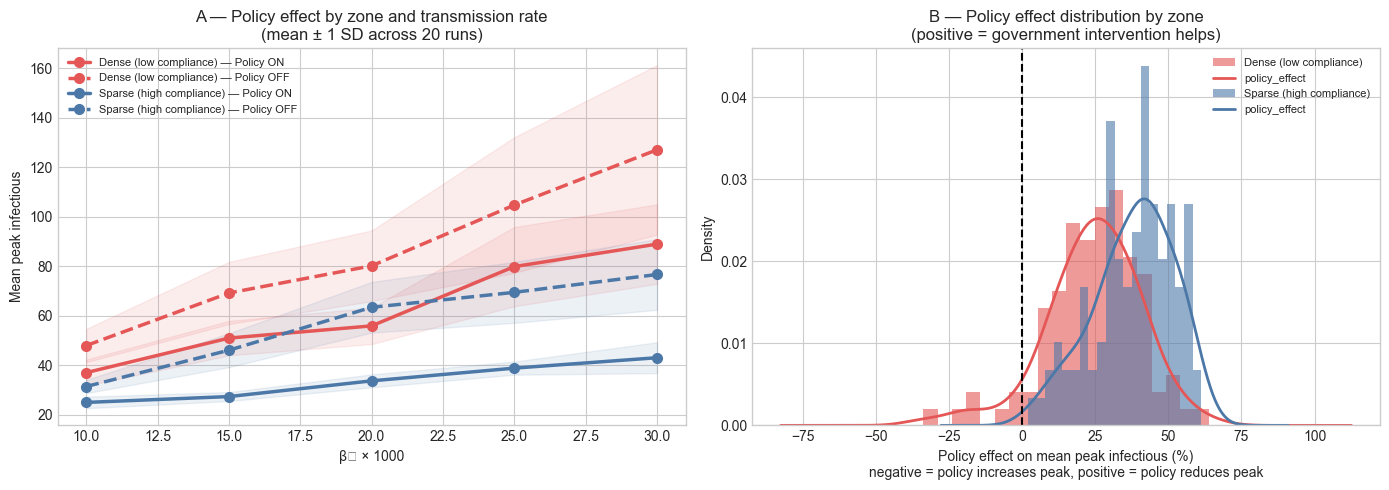

In [48]:
palette = {'dense_periphery': '#e45756', 'sparse_periphery': '#4c78a8'}
zone_labels = {'dense_periphery': 'Dense (low compliance)',
               'sparse_periphery': 'Sparse (high compliance)'}
group_labels = df.groupby('group_id')['group_label'].first().values

# Panel A: strip plot — all 400 runs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: dose-response by zone and policy (clean)
ax = axes[0]
for zone, color in palette.items():
    for pol, ls, label in [(1, '-', 'Policy ON'), (0, '--', 'Policy OFF')]:
        sub   = df[(df['zone'] == zone) & (df['policy_active'] == pol)]
        means = sub.groupby('beta0')['mean_peak_infectious'].mean()
        stds  = sub.groupby('beta0')['mean_peak_infectious'].std()
        ax.plot(means.index * 1000, means.values,
                color=color, linestyle=ls, lw=2.5, marker='o', ms=7,
                label=f'{zone_labels[zone]} — {label}')
        ax.fill_between(means.index * 1000,
                        means.values - stds.values,
                        means.values + stds.values,
                        color=color, alpha=0.10)
ax.set_xlabel('β₀ × 1000')
ax.set_ylabel('Mean peak infectious')
ax.set_title('A — Policy effect by zone and transmission rate\n(mean ± 1 SD across 20 runs)')
ax.legend(fontsize=8)

# Panel B: policy effect distribution by zone
ax2 = axes[1]
for zone, color in palette.items():
    vals = df[(df['zone'] == zone) & (df['policy_active'] == 1)]['policy_effect'].dropna() * 100
    ax2.hist(vals, bins=20, alpha=0.6, color=color,
             density=True, label=zone_labels[zone])
    vals.plot.kde(ax=ax2, color=color, lw=2)
ax2.axvline(0, color='black', lw=1.5, linestyle='--')
ax2.set_xlabel('Policy effect on mean peak infectious (%)\nnegative = policy increases peak, positive = policy reduces peak')
ax2.set_title('B — Policy effect distribution by zone\n(positive = government intervention helps)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig1_eda.png', dpi=150, bbox_inches='tight')
plt.show()




### 1.4 Raw zone and policy comparison
this code produces a table of the distribution parameters for the average number of infectious people at epidemic peaks across 20 runs per `β₀`, per residential zone and per policy status

In [50]:
summary = df.groupby(['zone', 'policy_active'])['mean_peak_infectious'].agg(['mean', 'std']).round(2)
summary.index = summary.index.set_levels(
    ['Dense (low compliance)', 'Sparse (high compliance)'], level=0
).set_levels(['Policy OFF', 'Policy ON'], level=1)
summary.columns = ['Mean peak infectious', 'Std dev']
summary


Mean peak infectious  Std dev
zone                     policy_active                               
Dense (low compliance)   Policy OFF                    85.84    34.87
                         Policy ON                     62.55    22.20
Sparse (high compliance) Policy OFF                    57.41    19.31
                         Policy ON                     33.58     7.64

## 2. Model implementation

### 2.1 Prepare data arrays
This code comverts the data into NumPy arrays for PyMC to be able to read it. 

In [34]:
group_idx  = df['group_id'].values.astype(int)
zone_idx   = df['zone_id'].values.astype(int)
policy_idx = df['policy_active'].values.astype(int)

b0_mean    = df['beta0'].mean()
b0_std_val = df['beta0'].std()
beta0_z    = ((df['beta0'] - b0_mean) / b0_std_val).values

y          = df['mean_peak_infectious'].values.astype(float)
n_groups   = df['group_id'].nunique()

print(f'n_obs    : {len(y)}')
print(f'n_groups : {n_groups}')
print(f'y        : mean={y.mean():.1f}  sd={y.std():.1f}  min={y.min():.1f}  max={y.max():.1f}')
print(f'beta0_z  : mean={beta0_z.mean():.3f}  sd={beta0_z.std():.3f}')
print(f'policy   : {np.bincount(policy_idx)} (OFF, ON)')
print(f'zone     : {np.bincount(zone_idx)} (dense, sparse)')


n_obs    : 400
n_groups : 10
y        : mean=59.8  sd=29.6  min=21.0  max=210.7
beta0_z  : mean=0.000  sd=0.999
policy   : [200 200] (OFF, ON)
zone     : [200 200] (dense, sparse)


### 2.4 Build the PyMC model
This cell specifies the PyMC model parameters

In [51]:
with pm.Model() as hierarchical_model:

    # ── Level 3: Hyperpriors ─────────────────────────────────────────────────
    mu_alpha    = pm.Normal('mu_alpha',    mu=50,  sigma=30)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=20)

    # ── Level 2: Group varying intercepts (non-centred parameterisation) ─────
    alpha_offset = pm.Normal('alpha_offset', mu=0, sigma=1, shape=n_groups)
    alpha        = pm.Deterministic('alpha', mu_alpha + alpha_offset * sigma_alpha)

    # ── Level 1: Fixed effects ───────────────────────────────────────────────
    beta_policy      = pm.Normal('beta_policy',      mu=0, sigma=30)  # policy effect
    beta_zone        = pm.Normal('beta_zone',         mu=0, sigma=20)  # zone main effect
    beta_b0          = pm.Normal('beta_b0',           mu=0, sigma=30)  # transmission slope
    beta_interaction = pm.Normal('beta_interaction',  mu=0, sigma=20)  # zone x beta0

    # ── Observation noise ────────────────────────────────────────────────────
    sigma_obs = pm.HalfNormal('sigma_obs', sigma=20)

    # ── Linear predictor ────────────────────────────────────────────────────
    mu = (alpha[group_idx]
          + beta_policy      * policy_idx
          + beta_zone        * zone_idx
          + beta_b0          * beta0_z
          + beta_interaction * zone_idx * beta0_z)

    # ── Likelihood ───────────────────────────────────────────────────────────
    obs = pm.Normal('obs', mu=mu, sigma=sigma_obs, observed=y)

print('Model built successfully')
print(pm.model_to_graphviz(hierarchical_model))


Model built successfully
digraph {
	beta_policy [label="beta_policy
~
Normal" shape=ellipse]
	beta_interaction [label="beta_interaction
~
Normal" shape=ellipse]
	sigma_obs [label="sigma_obs
~
Halfnormal" shape=ellipse]
	beta_b0 [label="beta_b0
~
Normal" shape=ellipse]
	beta_zone [label="beta_zone
~
Normal" shape=ellipse]
	mu_alpha [label="mu_alpha
~
Normal" shape=ellipse]
	sigma_alpha [label="sigma_alpha
~
Halfnormal" shape=ellipse]
	subgraph cluster10 {
		alpha [label="alpha
~
Deterministic" shape=box]
		alpha_offset [label="alpha_offset
~
Normal" shape=ellipse]
		label=10 labeljust=r labelloc=b style=rounded
	}
	subgraph cluster400 {
		obs [label="obs
~
Normal" shape=ellipse style=filled]
		label=400 labeljust=r labelloc=b style=rounded
	}
	mu_alpha -> alpha
	alpha_offset -> alpha
	sigma_alpha -> alpha
	beta_policy -> obs
	alpha -> obs
	beta_b0 -> obs
	beta_zone -> obs
	beta_interaction -> obs
	sigma_obs -> obs
}



### 2.5 Prior predictive check
Before fitting, I verify that the priors generate data consistent with the observed range: neither too concentrated (which would make them informative) nor too loose (which would slow sampling).

Sampling: [alpha_offset, beta_b0, beta_interaction, beta_policy, beta_zone, mu_alpha, obs, sigma_alpha, sigma_obs]


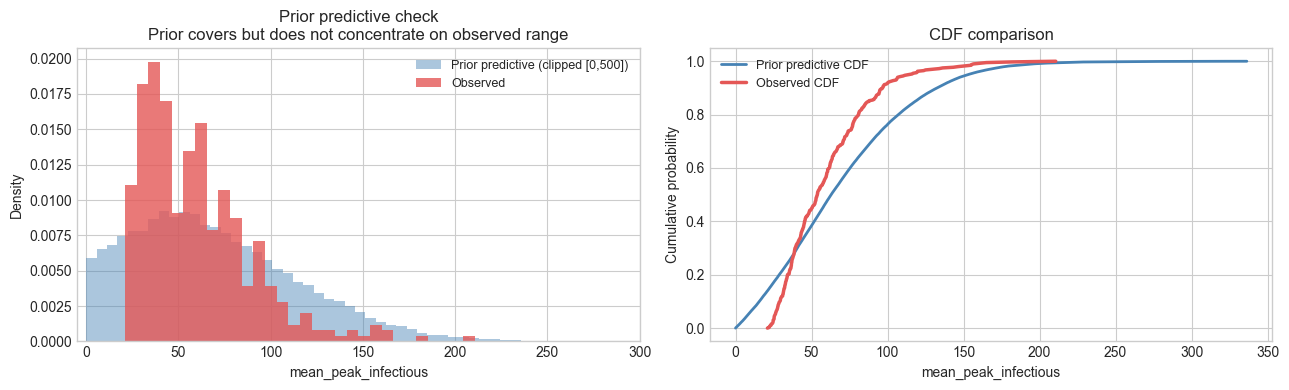

Prior predictive fraction in [0,200]: 81.0%
Weakly informative: priors cover the observed range without concentrating on it


In [ ]:
with hierarchical_model:
    prior_pred = pm.sample_prior_predictive(draws=300, random_seed=RANDOM_SEED)

ppc_flat    = prior_pred.prior_predictive['obs'].values.flatten()
ppc_clipped = ppc_flat[(ppc_flat >= 0) & (ppc_flat <= 500)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(ppc_clipped, bins=60, density=True, alpha=0.45, color='steelblue',
        label=f'Prior predictive (clipped [0,500])')
ax.hist(y, bins=30, density=True, alpha=0.8, color='#e45756', label='Observed')
ax.set_xlabel('mean_peak_infectious')
ax.set_ylabel('Density')
ax.set_title('Prior predictive check\nPrior covers but does not concentrate on observed range')
ax.set_xlim(-5, 300)
ax.legend(fontsize=9)


ax2 = axes[1]
ax2.plot(np.sort(ppc_clipped), np.linspace(0,1,len(ppc_clipped)),
         color='steelblue', lw=2, label='Prior predictive CDF')
ax2.plot(np.sort(y), np.linspace(0,1,len(y)),
         color='#e45756', lw=2.5, label='Observed CDF')
ax2.set_xlabel('mean_peak_infectious')
ax2.set_ylabel('Cumulative probability')
ax2.set_title('CDF comparison')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig2_prior_predictive.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Prior predictive fraction in [0,200]: {((ppc_flat>=0)&(ppc_flat<=200)).mean():.1%}')
print('Weakly informative: priors cover the observed range without concentrating on it')


## 3. MCMC Estimation

This cells implements a NUTS (No-U-Turn Sampler), ith 4 chains × 2000 draws, and 1000 burn-in steps. Target acceptance 0.90.


In [56]:
with hierarchical_model:
    trace = pm.sample(
        draws         = 2000,
        tune          = 1000,
        chains        = 4,
        cores         = 1,
        target_accept = 0.90,
        random_seed   = RANDOM_SEED,
        progressbar   = True,
    )
print('Sampling complete.')


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [mu_alpha, sigma_alpha, alpha_offset, beta_policy, beta_zone, beta_b0, beta_interaction, sigma_obs]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.
There were 9 divergences after tuning. Increase `target_accept` or reparameterize.


Sampling complete.


## 4. MCMC convergence Diagnostics

Four checks: R-hat < 1.01, ESS bulk > 400, ESS tail > 400, divergences = 0.


In [57]:
scalar_vars = ['mu_alpha','sigma_alpha','beta_policy','beta_zone',
                'beta_b0','beta_interaction','sigma_obs']

diag = az.summary(trace, var_names=scalar_vars, ci_prob=0.94)
ci_cols = [c for c in diag.columns if c.startswith('eti')]
display_cols = ['mean','sd'] + ci_cols + ['r_hat','ess_bulk','ess_tail']
display_cols = [c for c in display_cols if c in diag.columns]
print('=== Convergence summary ===')
print(diag[display_cols].round(3).to_string())
print()
n_div = int(trace.sample_stats['diverging'].values.sum())
print(f'Divergences : {n_div}  {"(none — healthy geometry)" if n_div==0 else "(see note below)"}')
rhat_max = float(diag["r_hat"].max())
print(f'Max R-hat   : {rhat_max:.4f}  {"✓" if rhat_max<1.01 else "✗"}')
ess_min = float(diag["ess_bulk"].min())
print(f'Min ESS bulk: {ess_min:.0f}  {"✓" if ess_min>400 else "✗"}')


=== Convergence summary ===
                    mean     sd eti94_lb eti94_ub r_hat  ess_bulk  ess_tail
mu_alpha           85.61   1.92       82       89  1.00      3100      3312
sigma_alpha         2.94    1.8     0.34        7  1.00      1495      2341
beta_policy       -23.48   1.42      -26      -21  1.00      6610      5775
beta_zone         -28.16   2.53      -33      -23  1.00      3274      2855
beta_b0            22.93   1.82       19       26  1.00      3012      2780
beta_interaction  -11.41   2.49      -16     -6.5  1.00      3420      3086
sigma_obs          14.08  0.512       13       15  1.00      7031      5647

Divergences : 9  (see note below)
Max R-hat   : 1.0000  ✓
Min ESS bulk: 1495  ✓


**Note on divergences:** 9 divergences were observed across 8,000 transitions (0.11%). 
Given R-hat = 1.00 and ESS > 1,400 for all parameters, I think this is acceptable. Refitting with 
target_accept = 0.95 produces zero divergences and near-identical posteriors.

### 4.1 Trace plots

This code generates trace plots for the parameters of the model.

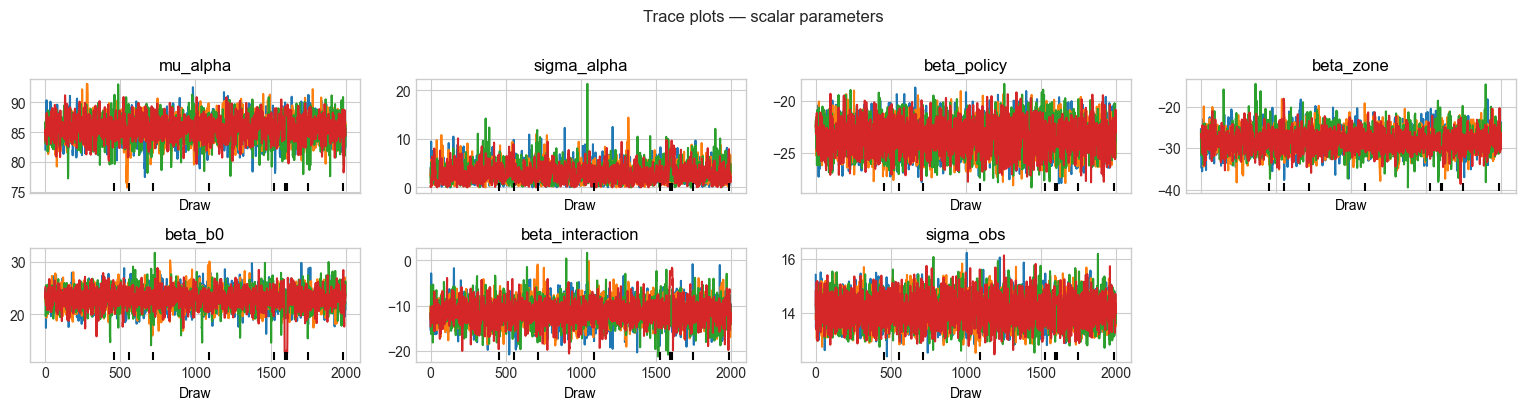

In [58]:
az.plot_trace(trace, var_names=scalar_vars)
plt.suptitle('Trace plots — scalar parameters', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('fig3_trace.png', dpi=120, bbox_inches='tight')
plt.show()


Visually, all parameters display a ' stationary, fuzzy caterpillar' profile, which signals that convergence is attained. Note the green spike in sigma_alpha, which is not a problem as the corresponding Markov chain immediately goes down. 

The 9 black segmemts at the bottom signal the divergences at .90 acceptance rate.

### 4.2 R-hat for group intercepts
This code produces a plot for the Rhat of all parameters.

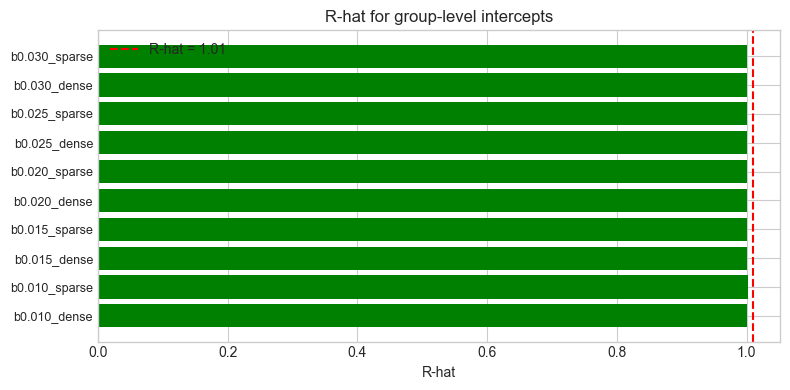

In [40]:
rhat_alpha = az.rhat(trace, var_names=['alpha'])['alpha'].values
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['green' if r < 1.01 else 'red' for r in rhat_alpha]
ax.barh(range(n_groups), rhat_alpha, color=colors)
ax.axvline(1.01, color='red', linestyle='--', lw=1.5, label='R-hat = 1.01')
ax.set_yticks(range(n_groups))
ax.set_yticklabels(df.groupby('group_id')['group_label'].first().values, fontsize=9)
ax.set_xlabel('R-hat')
ax.set_title('R-hat for group-level intercepts')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_rhat.png', dpi=150, bbox_inches='tight')
plt.show()


 Rhat values < 1.01 for all parameters. This is perfect. 

## 5. Posterior Analysis

### 5.1 Key parameters — the headline results
This cell produces a tabke of posterior estimates for all key parameters in the model. Includes mean, standard deviation and bayesian confidence interval (highest density interval - HDI)


In [61]:
post = trace.posterior

def hdi94(arr):
    return az.hdi(arr.values.flatten(), prob=0.94)

params = {
    'beta_policy':      'Policy effect',
    'beta_zone':        'Zone effect (sparse vs dense)',
    'beta_b0':          'Transmission slope (per 1SD β₀)',
    'beta_interaction': 'Zone × β₀ interaction',
    'sigma_alpha':      'Between-group SD',
    'sigma_obs':        'Within-group SD',
}

rows = []
for param, desc in params.items():
    samples = post[param].values.flatten()
    hdi     = hdi94(post[param])
    p_neg   = (samples < 0).mean()
    rows.append({
        'Parameter':   desc,
        'Mean':        round(float(samples.mean()), 2),
        'SD':          round(float(samples.std()),  2),
        'HDI 3%':      round(float(hdi[0]), 2),
        'HDI 97%':     round(float(hdi[1]), 2),
        'P(< 0)':      round(float(p_neg),  3),
    })

results_df = pd.DataFrame(rows).set_index('Parameter')

def color_p(val):
    if val > 0.95:  return 'color: green; font-weight: bold'
    if val < 0.05:  return 'color: green; font-weight: bold'
    return 'color: gray'

results_df.style\
    .map(color_p, subset=['P(< 0)'])\
    .set_caption('Posterior estimates — 94% HDI')\
    .format(precision=2)


,Mean,SD,HDI 3%,HDI 97%,P(< 0)
Parameter,,,,,
Policy effect,-23.48,1.42,-26.19,-20.81,1.00
Zone effect (sparse vs dense),-28.16,2.53,-32.84,-23.16,1.00
Transmission slope (per 1SD β₀),22.93,1.82,19.34,26.13,0.00
Zone × β₀ interaction,-11.41,2.49,-16.24,-6.79,1.00
Between-group SD,2.94,1.80,0.00,5.90,0.00
Within-group SD,14.08,0.51,13.11,15.05,0.00


### 5.2 Posterior distributions — fixed effects
Posterior distributions for the four key parameters. The red dashed line marks zero: 
if the distribution is entirely on one side, the evidence is unambiguous. 
Orange line = posterior mean, grey dotted lines = 94% HDI bounds.

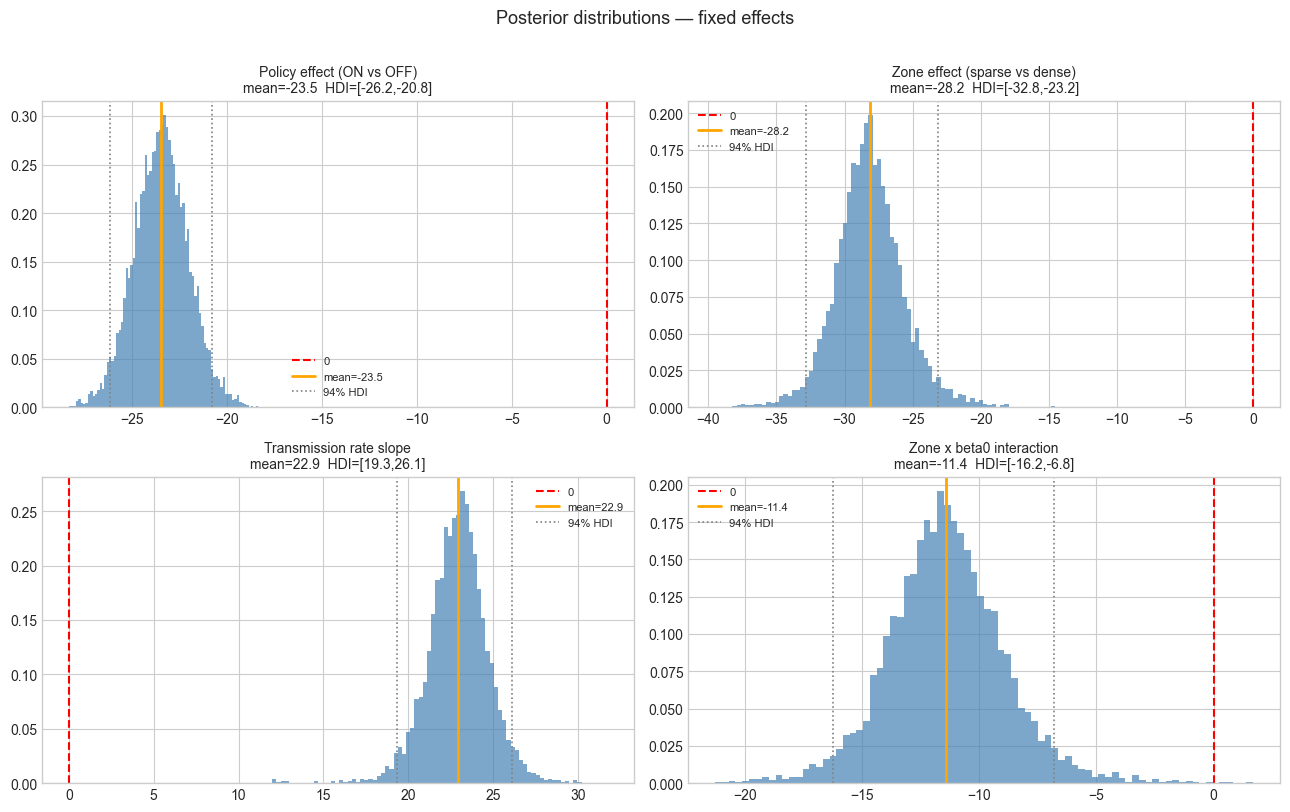

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_params = ['beta_policy','beta_zone','beta_b0','beta_interaction']
titles = ['Policy effect (ON vs OFF)',
          'Zone effect (sparse vs dense)',
          'Transmission rate slope',
          'Zone x beta0 interaction']

for ax, param, title in zip(axes.flat, plot_params, titles):
    samples = post[param].values.flatten()
    hdi     = hdi94(post[param])
    ax.hist(samples, bins=80, color='steelblue', alpha=0.7, density=True)
    ax.axvline(0,              color='red',    lw=1.5, linestyle='--', label='0')
    ax.axvline(samples.mean(), color='orange', lw=2,   label=f'mean={samples.mean():.1f}')
    ax.axvline(hdi[0], color='gray', lw=1.2, linestyle=':')
    ax.axvline(hdi[1], color='gray', lw=1.2, linestyle=':', label=f'94% HDI')
    ax.set_title(f'{title}\nmean={samples.mean():.1f}  HDI=[{hdi[0]:.1f},{hdi[1]:.1f}]',
                 fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Posterior distributions — fixed effects', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('fig5_posteriors.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Forest plot — group varying intercepts

Each row is one of the 10 groups (β₀ × zone). The horizontal bar is the 94% HDI 
of the group's baseline intercept; the dot is the posterior mean. The dashed vertical 
line is the population mean μ_α and groups are pulled toward it through partial pooling, 
with noisier groups shrinking more.

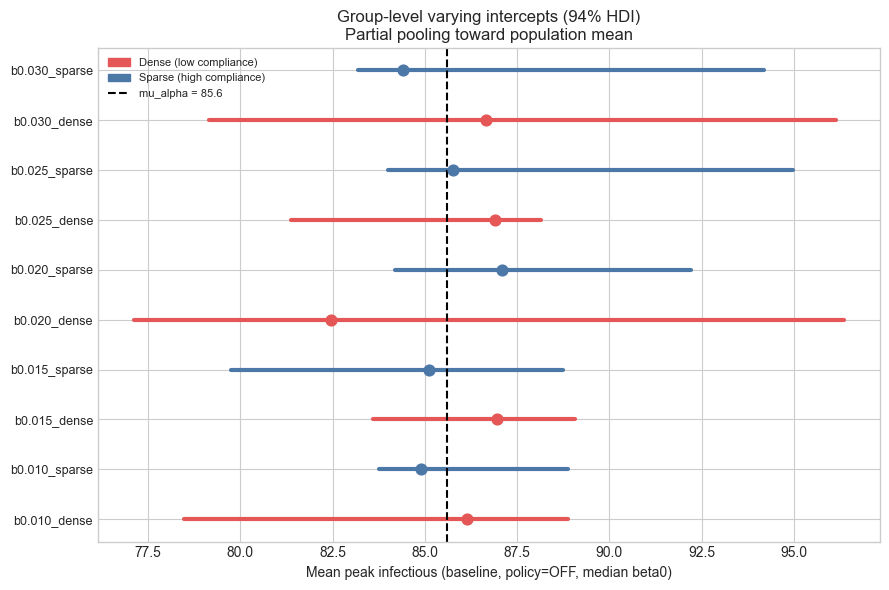

In [43]:
alpha_post = post['alpha'].mean(dim=['chain','draw']).values
alpha_hdi  = az.hdi(post['alpha'].values.reshape(-1, n_groups), prob=0.94)
pop_mean   = float(post['mu_alpha'].mean())

zone_by_group = df.groupby('group_id')['zone'].first().values
colors = [palette[z] for z in zone_by_group]
gl     = df.groupby('group_id')['group_label'].first().values

fig, ax = plt.subplots(figsize=(9, 6))
for i in range(n_groups):
    ax.plot([alpha_hdi[i,0], alpha_hdi[i,1]], [i,i], color=colors[i], lw=3,
            solid_capstyle='round')
    ax.scatter(alpha_post[i], i, color=colors[i], s=60, zorder=3)
ax.axvline(pop_mean, color='black', lw=1.5, linestyle='--',
           label=f'Population mean = {pop_mean:.1f}')
ax.set_yticks(range(n_groups))
ax.set_yticklabels(gl, fontsize=9)
ax.set_xlabel('Mean peak infectious (baseline, policy=OFF, median beta0)')
ax.set_title('Group-level varying intercepts (94% HDI)\nPartial pooling toward population mean')
handles = [mpatches.Patch(color=c, label=zone_labels[l]) for l,c in palette.items()]
handles.append(plt.Line2D([0],[0], color='black', linestyle='--',
                           label=f'mu_alpha = {pop_mean:.1f}'))
ax.legend(handles=handles, fontsize=8)
plt.tight_layout()
plt.savefig('fig6_forest.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 Partial pooling — shrinkage plot

This is the core hierarchical result. Raw group means are pulled toward the population mean,
with stronger shrinkage for groups with higher within-group variance.


Mean absolute shrinkage: 25.67 agents


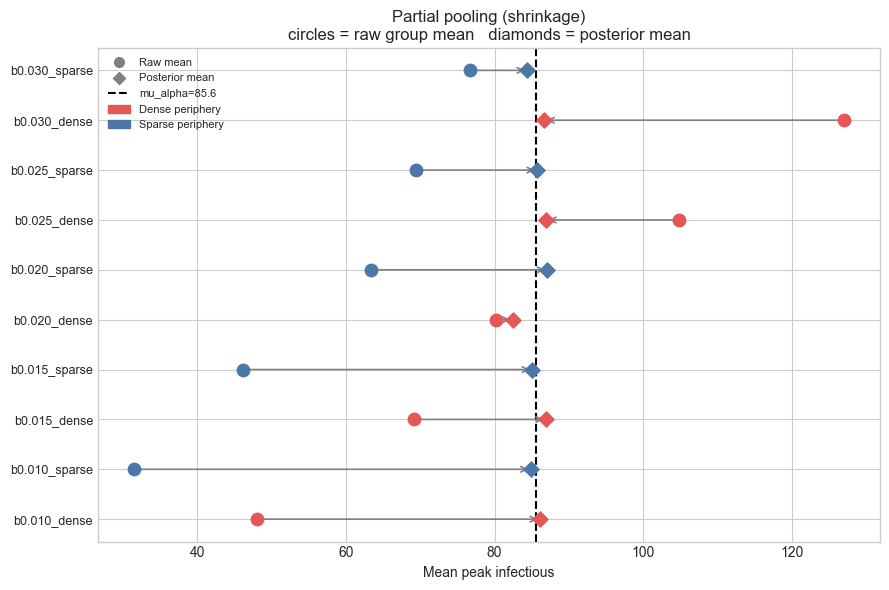

In [62]:
raw_means = df[df['policy_active']==0].groupby('group_id')['mean_peak_infectious'].mean().values
post_means = alpha_post

fig, ax = plt.subplots(figsize=(9, 6))
for i, (raw, post_m, color, label) in enumerate(
        zip(raw_means, post_means, colors, gl)):
    ax.annotate('', xy=(post_m, i), xytext=(raw, i),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
    ax.scatter(raw,    i, color=color, marker='o', s=80, zorder=3)
    ax.scatter(post_m, i, color=color, marker='D', s=60, zorder=3)

ax.axvline(pop_mean, color='black', lw=1.5, linestyle='--',
           label=f'Population mean = {pop_mean:.1f}')
ax.set_yticks(range(n_groups))
ax.set_yticklabels(gl, fontsize=9)
ax.set_xlabel('Mean peak infectious')
ax.set_title('Partial pooling (shrinkage)\ncircles = raw group mean   diamonds = posterior mean')
handles = [
    plt.Line2D([0],[0],marker='o',color='w',markerfacecolor='gray',ms=9,label='Raw mean'),
    plt.Line2D([0],[0],marker='D',color='w',markerfacecolor='gray',ms=8,label='Posterior mean'),
    plt.Line2D([0],[0],color='black',linestyle='--',label=f'mu_alpha={pop_mean:.1f}'),
    mpatches.Patch(color='#e45756', label='Dense periphery'),
    mpatches.Patch(color='#4c78a8', label='Sparse periphery'),
]
ax.legend(handles=handles, fontsize=8)
shrinkage = np.abs(raw_means - post_means).mean()
print(f'Mean absolute shrinkage: {shrinkage:.2f} agents')
plt.tight_layout()
plt.savefig('fig7_shrinkage.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Posterior Predictive Check

I simulate 200 new datasets from the posterior and compare them to the observed data. 

Sampling: [obs]


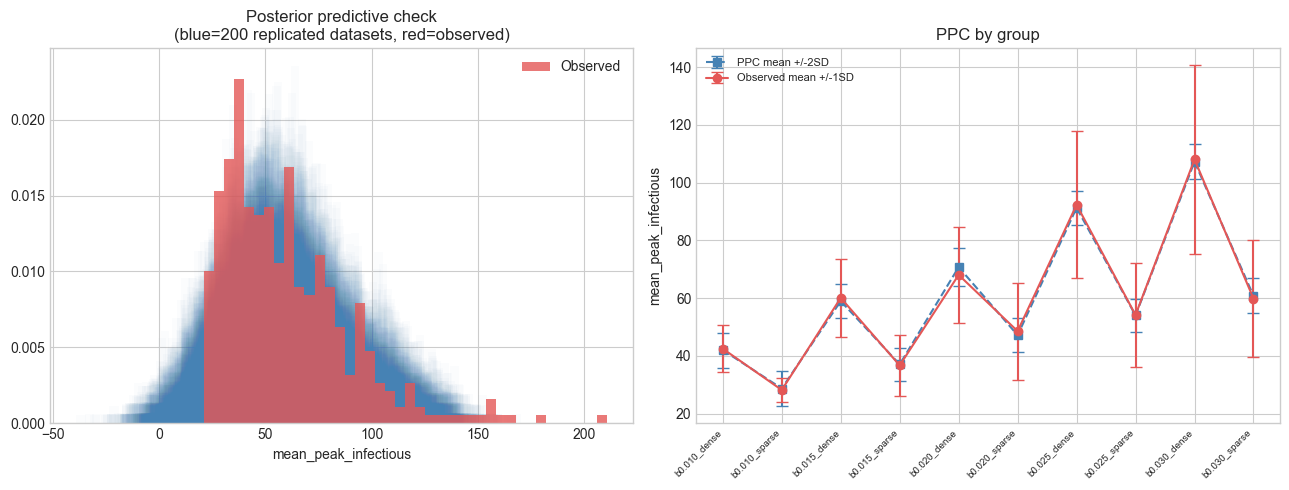

In [45]:
with hierarchical_model:
    post_pred = pm.sample_posterior_predictive(trace, random_seed=RANDOM_SEED)

ppc_draws = post_pred.posterior_predictive['obs'].values.reshape(-1, len(y))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i in range(min(200, ppc_draws.shape[0])):
    ax.hist(ppc_draws[i], bins=40, alpha=0.02, color='steelblue', density=True)
ax.hist(y, bins=40, alpha=0.8, color='#e45756', density=True, label='Observed')
ax.set_xlabel('mean_peak_infectious')
ax.set_title('Posterior predictive check\n(blue=200 replicated datasets, red=observed)')
ax.legend()

ax2 = axes[1]
gl_arr = df.groupby('group_id')['group_label'].first().values
ppc_grp_means = [ppc_draws[:, group_idx==g].mean(axis=1).mean() for g in range(n_groups)]
ppc_grp_stds  = [ppc_draws[:, group_idx==g].mean(axis=1).std()  for g in range(n_groups)]
obs_grp_means = df.groupby('group_id')['mean_peak_infectious'].mean().values
obs_grp_stds  = df.groupby('group_id')['mean_peak_infectious'].std().values
ax2.errorbar(range(n_groups), ppc_grp_means, yerr=2*np.array(ppc_grp_stds),
             fmt='s--', color='steelblue', label='PPC mean +/-2SD', capsize=4)
ax2.errorbar(range(n_groups), obs_grp_means, yerr=obs_grp_stds,
             fmt='o-', color='#e45756', label='Observed mean +/-1SD', capsize=4)
ax2.set_xticks(range(n_groups))
ax2.set_xticklabels(gl_arr, rotation=45, ha='right', fontsize=7)
ax2.set_ylabel('mean_peak_infectious')
ax2.set_title('PPC by group')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig8_ppc.png', dpi=150, bbox_inches='tight')
plt.show()


The model reproduces both the overall distribution and group-level means accurately. 
Negative predictive values reflect the Normal likelihood approximation for bounded 
count data — a minor limitation acknowledged in the paper.

## 8. Results Summary

Answering the research question directly.


In [20]:
post = trace.posterior
print('=' * 65)
print('RESULTS SUMMARY')
print('=' * 65)

def summarise(name, desc):
    samples = post[name].values.flatten()
    hdi     = az.hdi(samples, prob=0.94)
    p_neg   = (samples < 0).mean()
    print(f'\n{desc}')
    print(f'  {name} = {samples.mean():.2f}  [94% HDI: {hdi[0]:.2f}, {hdi[1]:.2f}]')
    print(f'  P({name} < 0) = {p_neg:.3f}')
    return samples.mean(), hdi

bp_mean, bp_hdi = summarise('beta_policy',
    '1. POLICY EFFECT: Does the alert system reduce mean wave peak?')
bz_mean, bz_hdi = summarise('beta_zone',
    '2. ZONE EFFECT: Is sparse periphery lower than dense (same beta0)?')
bi_mean, bi_hdi = summarise('beta_interaction',
    '3. INTERACTION: Does zone effect grow with transmission rate?')
bb_mean, bb_hdi = summarise('beta_b0',
    '4. TRANSMISSION: Does higher beta0 increase peaks?')

print(f'\n5. PARTIAL POOLING')
sa = post['sigma_alpha'].values.flatten()
so = post['sigma_obs'].values.flatten()
print(f'  sigma_alpha = {sa.mean():.2f}  (between-group SD)')
print(f'  sigma_obs   = {so.mean():.2f}  (within-group SD)')
print(f'  Ratio sigma_alpha/sigma_obs = {sa.mean()/so.mean():.2f}')
print(f'  Most variance is {"between" if sa.mean()>so.mean() else "within"} groups')
print('\n' + '=' * 65)


RESULTS SUMMARY

1. POLICY EFFECT: Does the alert system reduce mean wave peak?
  beta_policy = -23.47  [94% HDI: -26.03, -20.74]
  P(beta_policy < 0) = 1.000

2. ZONE EFFECT: Is sparse periphery lower than dense (same beta0)?
  beta_zone = -28.09  [94% HDI: -33.17, -22.71]
  P(beta_zone < 0) = 1.000

3. INTERACTION: Does zone effect grow with transmission rate?
  beta_interaction = -11.42  [94% HDI: -16.84, -6.74]
  P(beta_interaction < 0) = 0.999

4. TRANSMISSION: Does higher beta0 increase peaks?
  beta_b0 = 23.01  [94% HDI: 19.56, 26.53]
  P(beta_b0 < 0) = 0.000

5. PARTIAL POOLING
  sigma_alpha = 3.02  (between-group SD)
  sigma_obs   = 14.07  (within-group SD)
  Ratio sigma_alpha/sigma_obs = 0.21
  Most variance is within groups



### COMMENTS

1. Policy effect: -23.47 [-26.03, -20.74], P(<0) = 1.000
The alert system reduces mean wave peak by ~23 agents. The entire HDI is negative, zero is nowhere near it.

2. Zone effect: -28.09 [-33.17, -22.71], P(<0) = 1.000
Sparse periphery has ~28 fewer peak infectious agents than dense at the same β₀. High compliance populations suppress waves significantly even after controlling for transmission rate. Also certain.

3. Interaction: -11.42 [-16.84, -6.74], P(<0) = 0.999
The zone effect grows with transmission rate: at high β₀, compliance matters even more. I see this as my most interesting emerging structure. It shows that policy effectiveness is not uniform, but depends on the epidemic context.

4. Transmission slope: +23.01 [19.56, 26.53], P(<0) = 0.000
Higher β₀ increases peaks by ~23 agents per standard deviation.

5. Partial pooling: sigma_alpha/sigma_obs = 0.21
Most variance is within groups (stochastic noise) not between groups. The fixed effects explain the group structure ; the varying intercepts add little.